# Bike Sharing Demand Prediction — Model Building & Evaluation

Trains 7 regressors, runs cross-validation, plots residuals, and tunes the best performer with GridSearchCV.

## 1. Imports & Load Cleaned Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

from utils import (
    evaluate_model, plot_residuals, plot_pred_vs_actual,
    cross_validate_model, compare_models,
)

sns.set_style('whitegrid')
%matplotlib inline

In [2]:
df = pd.read_csv('data/bike_sharing_cleaned.csv')
print('Shape:', df.shape)
df.head()

Shape: (17379, 21)


,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,...,windspeed,cnt,hr_sin,hr_cos,IsRushHour,IsNight,mnth_sin,mnth_cos,IsWeekend,ComfortIndex
0,1,0,1,0,0,6,0,1,0.24,0.2879,...,0.0,16,0.000000,1.000000,0,1,0.5,0.866025,1,-0.165
1,1,0,1,1,0,6,0,1,0.22,0.2727,...,0.0,40,0.258819,0.965926,0,1,0.5,0.866025,1,-0.180
2,1,0,1,2,0,6,0,1,0.22,0.2727,...,0.0,32,0.500000,0.866025,0,1,0.5,0.866025,1,-0.180
3,1,0,1,3,0,6,0,1,0.24,0.2879,...,0.0,13,0.707107,0.707107,0,1,0.5,0.866025,1,-0.135
4,1,0,1,4,0,6,0,1,0.24,0.2879,...,0.0,1,0.866025,0.500000,0,1,0.5,0.866025,1,-0.135


## 2. Train / Test Split & Scaling

In [3]:
X = df.drop(columns=['cnt'])
y = df['cnt']
print('Features:', X.shape[1])
print('Target stats:'); print(y.describe().round(2))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('Train:', X_train.shape, 'Test:', X_test.shape)

Features: 20
Target stats:
count    17379.00
mean       189.46
std        181.39
min          1.00
25%         40.00
50%        142.00
75%        281.00
max        977.00
Name: cnt, dtype: float64
Train: (13903, 20) Test: (3476, 20)


## 3. Train 7 Regressors

In [4]:
results = []
models = {}


  Linear Regression
  MAE   : 78.8330
  RMSE  : 105.9720
  R2    : 0.6454
  MAPE  : 1.5155


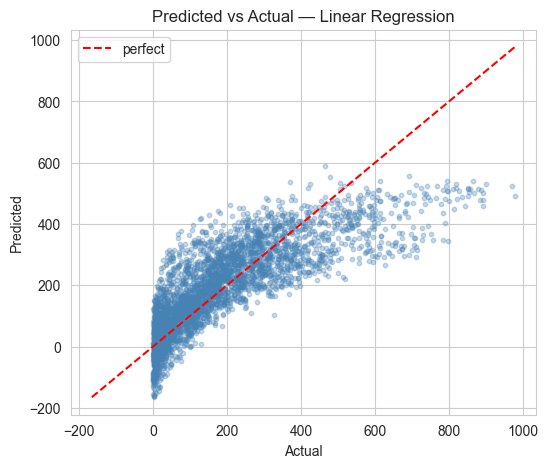

In [5]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)
results.append(evaluate_model('Linear Regression', y_test, y_pred))
models['Linear Regression'] = ('scaled', lr)
plot_pred_vs_actual(y_test, y_pred, 'Linear Regression'); plt.show()


  Ridge
  MAE   : 78.8317
  RMSE  : 105.9722
  R2    : 0.6454
  MAPE  : 1.5155


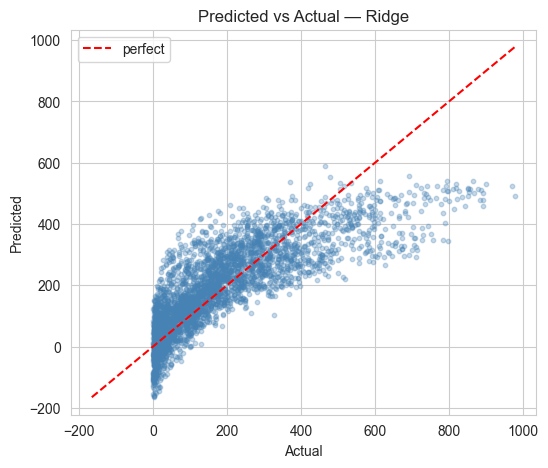

In [6]:
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train_scaled, y_train)
y_pred = ridge.predict(X_test_scaled)
results.append(evaluate_model('Ridge', y_test, y_pred))
models['Ridge'] = ('scaled', ridge)
plot_pred_vs_actual(y_test, y_pred, 'Ridge'); plt.show()


  Lasso
  MAE   : 78.7706
  RMSE  : 105.9762
  R2    : 0.6453
  MAPE  : 1.5161


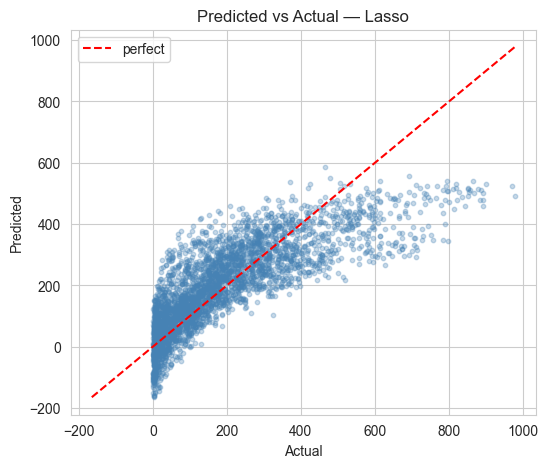

In [7]:
lasso = Lasso(alpha=0.1, random_state=42, max_iter=10000)
lasso.fit(X_train_scaled, y_train)
y_pred = lasso.predict(X_test_scaled)
results.append(evaluate_model('Lasso', y_test, y_pred))
models['Lasso'] = ('scaled', lasso)
plot_pred_vs_actual(y_test, y_pred, 'Lasso'); plt.show()


  Decision Tree
  MAE   : 35.5055
  RMSE  : 58.7181
  R2    : 0.8911
  MAPE  : 0.3899


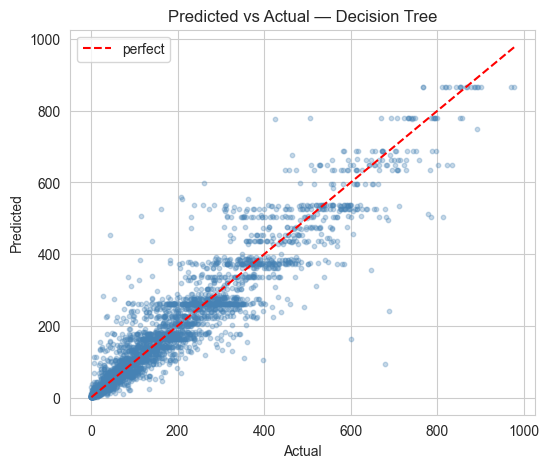

In [8]:
dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
results.append(evaluate_model('Decision Tree', y_test, y_pred))
models['Decision Tree'] = ('raw', dt)
plot_pred_vs_actual(y_test, y_pred, 'Decision Tree'); plt.show()


  Random Forest
  MAE   : 25.0609
  RMSE  : 42.6010
  R2    : 0.9427
  MAPE  : 0.3142


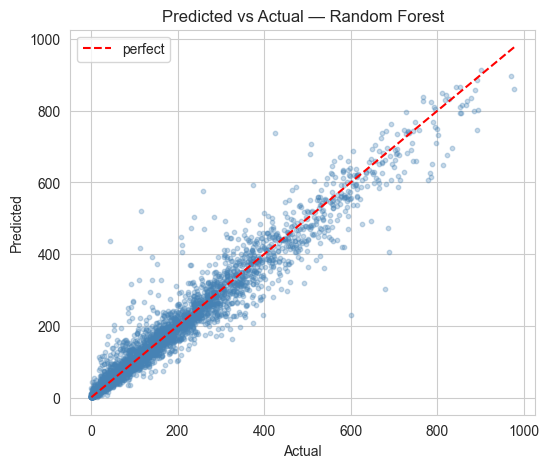

In [9]:
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
results.append(evaluate_model('Random Forest', y_test, y_pred))
models['Random Forest'] = ('raw', rf)
plot_pred_vs_actual(y_test, y_pred, 'Random Forest'); plt.show()

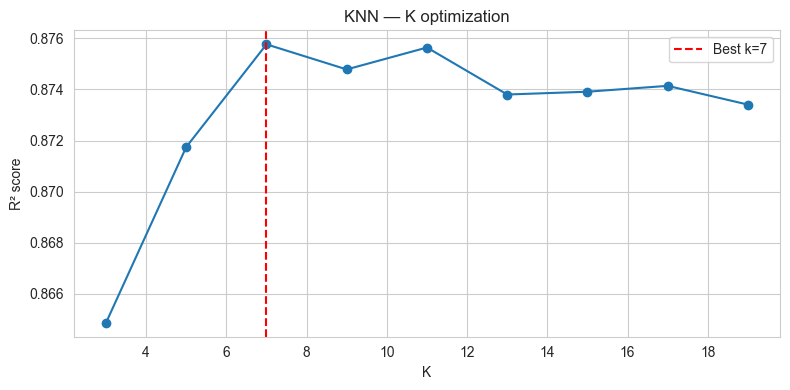


  KNN (k=7)
  MAE   : 40.9134
  RMSE  : 62.7211
  R2    : 0.8758
  MAPE  : 0.6116


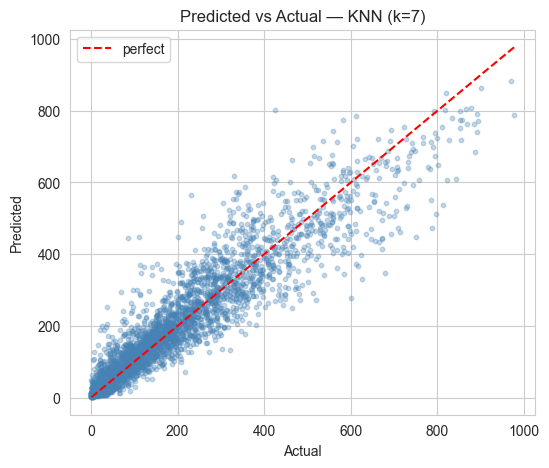

In [10]:
k_range = range(3, 21, 2)
from sklearn.metrics import r2_score
k_scores = []
for k in k_range:
    knn_t = KNeighborsRegressor(n_neighbors=k, n_jobs=-1)
    knn_t.fit(X_train_scaled, y_train)
    k_scores.append(r2_score(y_test, knn_t.predict(X_test_scaled)))
best_k = list(k_range)[int(np.argmax(k_scores))]
plt.figure(figsize=(8, 4)); plt.plot(list(k_range), k_scores, marker='o')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
plt.xlabel('K'); plt.ylabel('R² score'); plt.title('KNN — K optimization')
plt.legend(); plt.tight_layout(); plt.show()
knn = KNeighborsRegressor(n_neighbors=best_k, n_jobs=-1)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)
knn_label = f'KNN (k={best_k})'
results.append(evaluate_model(knn_label, y_test, y_pred))
models[knn_label] = ('scaled', knn)
plot_pred_vs_actual(y_test, y_pred, knn_label); plt.show()


  Gradient Boosting
  MAE   : 34.4279
  RMSE  : 51.4728
  R2    : 0.9163
  MAPE  : 0.5620


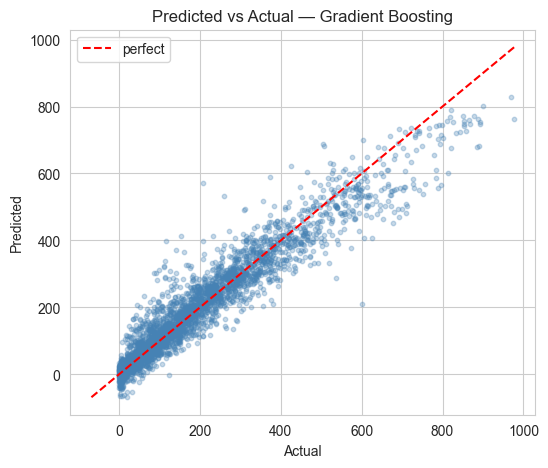

In [11]:
gb = GradientBoostingRegressor(n_estimators=200, random_state=42)
gb.fit(X_train, y_train)
y_pred = gb.predict(X_test)
results.append(evaluate_model('Gradient Boosting', y_test, y_pred))
models['Gradient Boosting'] = ('raw', gb)
plot_pred_vs_actual(y_test, y_pred, 'Gradient Boosting'); plt.show()

## 4. Feature Importance — Tree Models

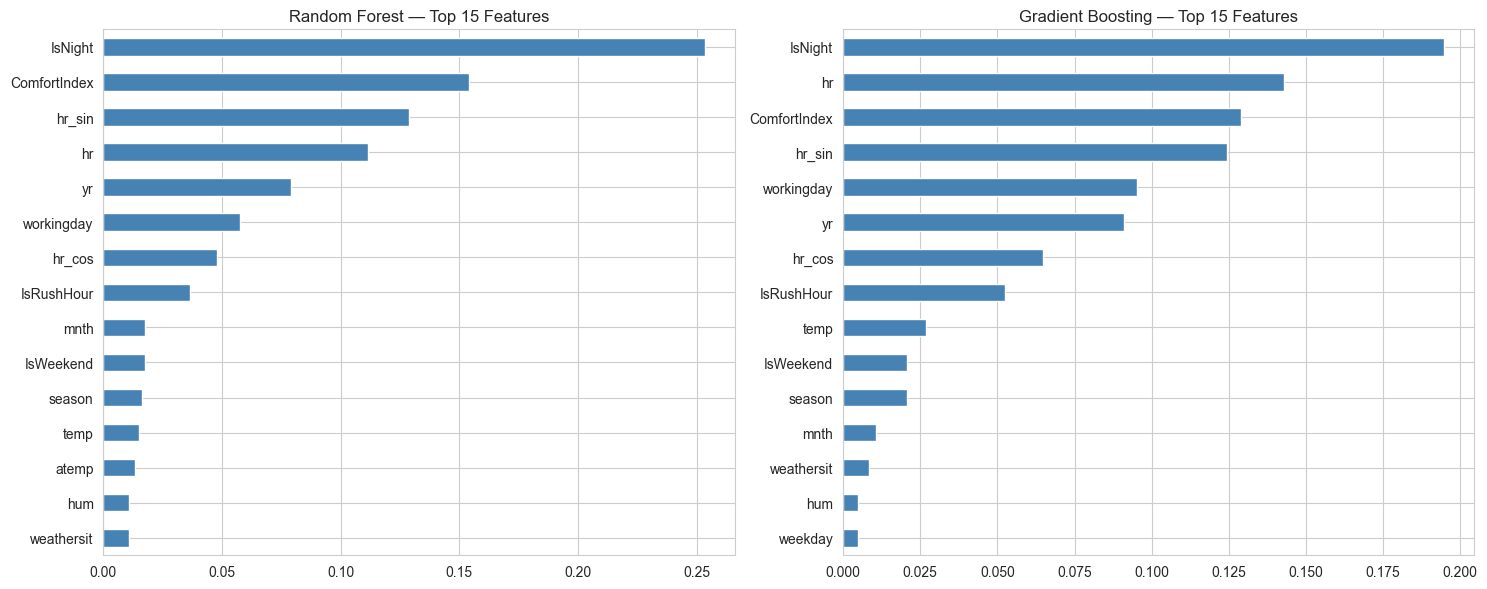

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, (name, model) in zip(axes, [('Random Forest', rf), ('Gradient Boosting', gb)]):
    importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True).tail(15)
    importances.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'{name} — Top 15 Features')
plt.tight_layout(); plt.show()

## 5. Model Comparison

In [13]:
comparison = compare_models(results)
comparison

,Model,MAE,RMSE,R2,MAPE
0,Random Forest,25.060941,42.600967,0.942687,0.314208
1,Gradient Boosting,34.427940,51.472809,0.916330,0.561987
2,Decision Tree,35.505460,58.718071,0.891117,0.389862
3,KNN (k=7),40.913365,62.721064,0.875766,0.611556
4,Linear Regression,78.832962,105.972031,0.645352,1.515474
5,Ridge,78.831676,105.972181,0.645351,1.515485
6,Lasso,78.770636,105.976159,0.645324,1.516055


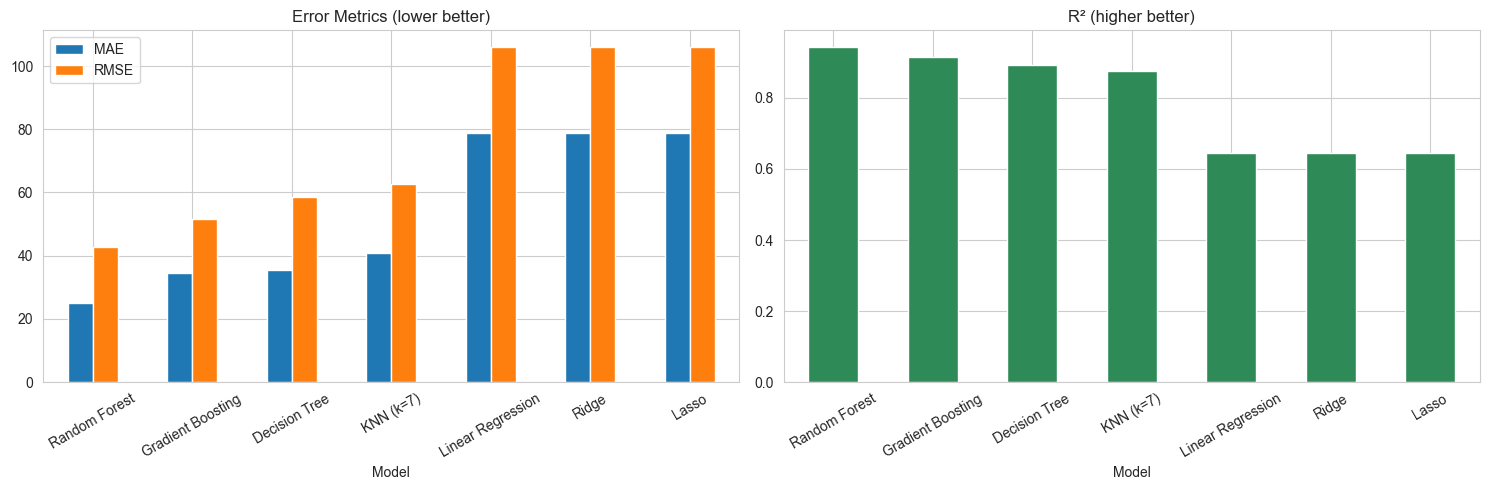

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
comparison.set_index('Model')[['MAE', 'RMSE']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Error Metrics (lower better)')
axes[0].tick_params(axis='x', rotation=30)
comparison.set_index('Model')[['R2']].plot(kind='bar', ax=axes[1], color='seagreen', legend=False)
axes[1].set_title('R² (higher better)')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

## 6. 5-Fold Cross-Validation

In [15]:
cv_scores = {}
X_full_scaled = scaler.fit_transform(X)
for name, (kind, model) in models.items():
    if kind == 'scaled':
        scores = cross_val_score(model, X_full_scaled, y, cv=5, scoring='r2', n_jobs=-1)
    else:
        scores = cross_val_score(model, X, y, cv=5, scoring='r2', n_jobs=-1)
    cv_scores[name] = scores
    print(f'{name:25s} mean R² = {scores.mean():.4f} (+/- {scores.std():.4f})')

Linear Regression         mean R² = 0.5020 (+/- 0.1367)


Ridge                     mean R² = 0.5020 (+/- 0.1363)


Lasso                     mean R² = 0.5026 (+/- 0.1353)


Decision Tree             mean R² = 0.7075 (+/- 0.1402)


Random Forest             mean R² = 0.8067 (+/- 0.0859)


KNN (k=7)                 mean R² = 0.5664 (+/- 0.2341)


Gradient Boosting         mean R² = 0.8209 (+/- 0.0741)


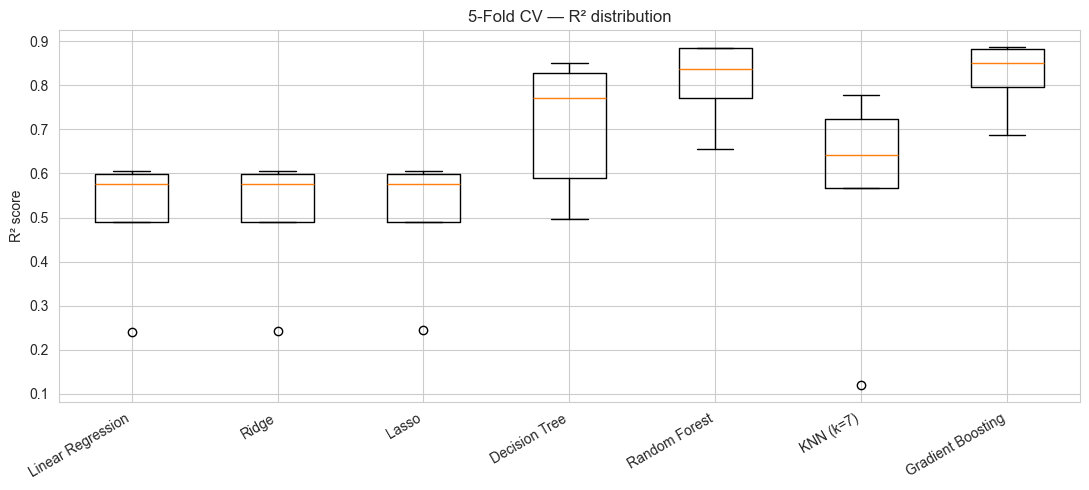

In [16]:
plt.figure(figsize=(11, 5))
plt.boxplot([cv_scores[k] for k in cv_scores], labels=list(cv_scores.keys()))
plt.xticks(rotation=30, ha='right'); plt.ylabel('R² score')
plt.title('5-Fold CV — R² distribution'); plt.tight_layout(); plt.show()

## 7. Residuals — Best Model

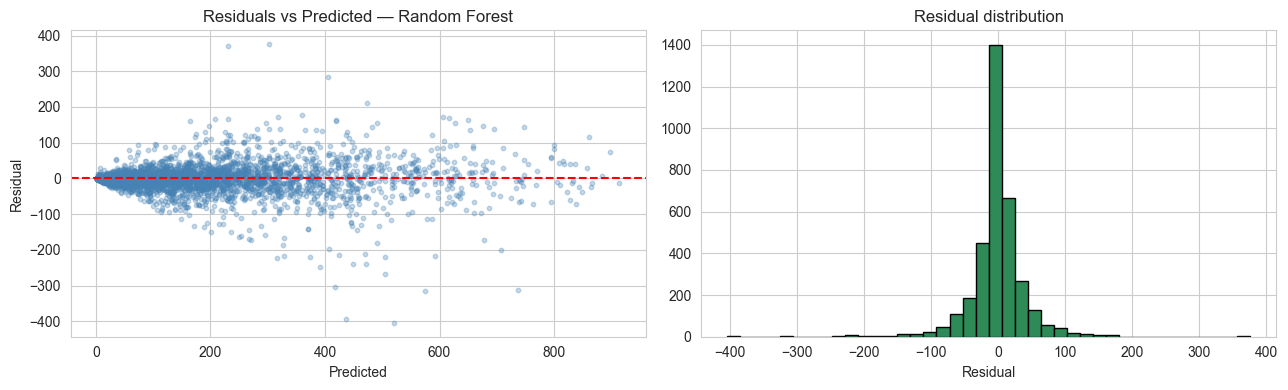

In [17]:
best_model_name = comparison.iloc[0]['Model']
kind, best_pre = models[best_model_name]
Xt = X_test_scaled if kind == 'scaled' else X_test
y_pred_best = best_pre.predict(Xt)
plot_residuals(y_test, y_pred_best, best_model_name); plt.show()

## 8. Hyperparameter Tuning — Best Performer

Best params: {'max_depth': 25, 'min_samples_leaf': 1, 'n_estimators': 200}
Best CV R²: 0.9389



  Random Forest (Tuned)
  MAE   : 25.0374
  RMSE  : 42.6223
  R2    : 0.9426
  MAPE  : 0.3135


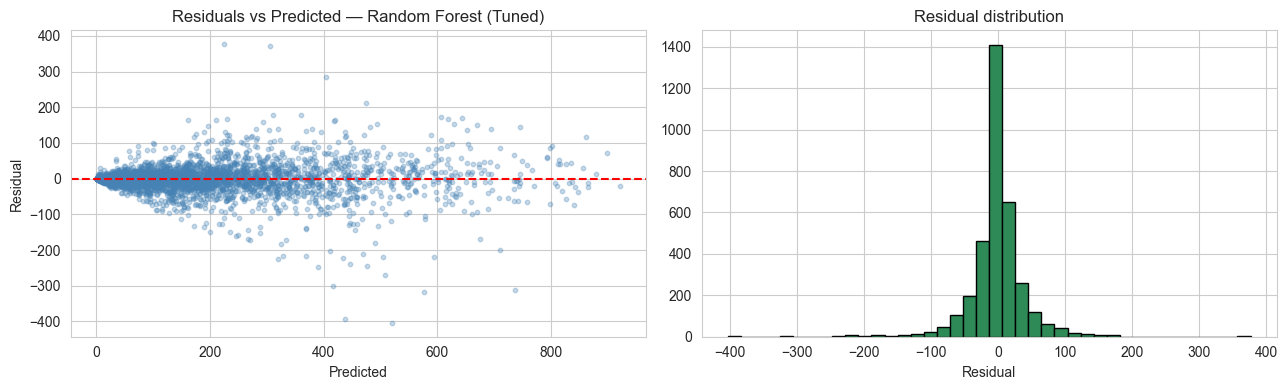

In [18]:
param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [None, 15, 25],
    'min_samples_leaf': [1, 2],
}
rf_tuned = RandomForestRegressor(random_state=42, n_jobs=-1)
grid = GridSearchCV(rf_tuned, param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=0)
grid.fit(X_train, y_train)
print('Best params:', grid.best_params_)
print('Best CV R²:', round(grid.best_score_, 4))
best = grid.best_estimator_
y_pred = best.predict(X_test)
tuned_metrics = evaluate_model('Random Forest (Tuned)', y_test, y_pred)
results.append(tuned_metrics)
plot_residuals(y_test, y_pred, 'Random Forest (Tuned)'); plt.show()

## 9. Tuned Model — Feature Importance

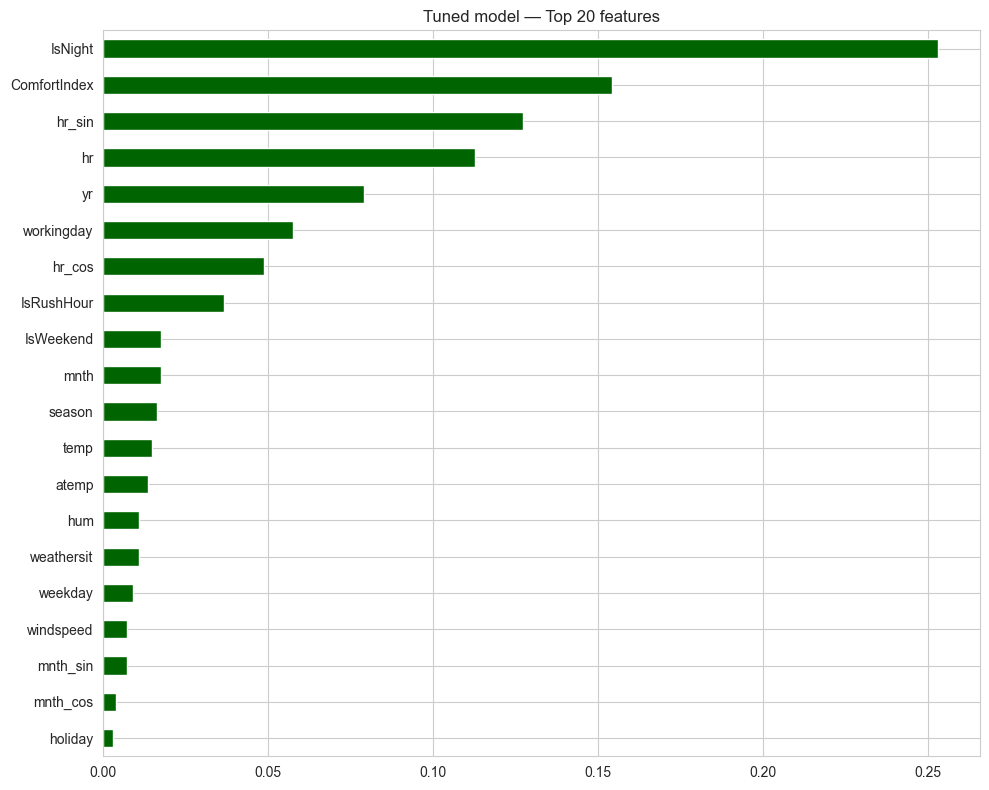

In [19]:
if hasattr(best, 'feature_importances_'):
    importances = pd.Series(best.feature_importances_, index=X.columns).sort_values(ascending=True).tail(20)
    plt.figure(figsize=(10, 8))
    importances.plot(kind='barh', color='darkgreen')
    plt.title('Tuned model — Top 20 features'); plt.tight_layout(); plt.show()
elif hasattr(best, 'coef_'):
    importances = pd.Series(np.abs(best.coef_), index=X.columns).sort_values(ascending=True).tail(20)
    plt.figure(figsize=(10, 8))
    importances.plot(kind='barh', color='darkgreen')
    plt.title('Tuned model — Top 20 |coefficients|'); plt.tight_layout(); plt.show()

## 10. Sample Prediction

In [20]:
sample = X_test.iloc[:5].copy()
preds = best.predict(sample)
out = pd.DataFrame({'Predicted': preds.round(2), 'Actual': y_test.iloc[:5].values.round(2)})
out['AbsError'] = (out['Predicted'] - out['Actual']).abs().round(2)
out

,Predicted,Actual,AbsError
0,384.86,425,40.14
1,134.88,88,46.88
2,10.52,4,6.52
3,548.47,526,22.47
4,15.30,13,2.30


## 11. Final Summary

In [21]:
final = compare_models(results)
final

,Model,MAE,RMSE,R2,MAPE
0,Random Forest,25.060941,42.600967,0.942687,0.314208
1,Random Forest (Tuned),25.037386,42.622315,0.942629,0.313482
2,Gradient Boosting,34.427940,51.472809,0.916330,0.561987
3,Decision Tree,35.505460,58.718071,0.891117,0.389862
4,KNN (k=7),40.913365,62.721064,0.875766,0.611556
5,Linear Regression,78.832962,105.972031,0.645352,1.515474
6,Ridge,78.831676,105.972181,0.645351,1.515485
7,Lasso,78.770636,105.976159,0.645324,1.516055


### Key Takeaways

- Bike Sharing Demand Prediction: regression on `cnt`.
- 7 regressors + 1 tuned variant evaluated on MAE / RMSE / R² / MAPE.
- Tree-based models highlight the most predictive features.
- Predicted-vs-actual scatter plots reveal where models systematically over/underestimate.

### Next Steps

- Try gradient boosters (XGBoost, LightGBM) for further gains.
- Apply log-transform on skewed targets and re-fit.
- Add domain-specific feature engineering.